In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
true_time=data['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps0 to 140
res='1km'
index_adjust=0
ocean_fraction=0.25


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(PlottingFunctions, inspect.isfunction)]
# functions

In [3]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}.h5'
# in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_TEST.h5'
with h5py.File(in_file, 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]

    # W = f['W'][:]
    # QCQI = f['QCQI'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [4]:
#READING BACK IN
mins_thresh=5
# mins_thresh=10
dir3=dir+f'Project_Algorithms/Entrainment/processed_binary_arrays_'+str(mins_thresh)+f'mins_{res}_{Np_str}.h5'
with h5py.File(dir3, 'r') as h5file:
    A_g_Processed = h5file['A_g_Processed'][:]
    A_c_Processed = h5file['A_c_Processed'][:]

In [ ]:
# #DOMAIN SUBSETTING
# ocean_percent=2/8

# left_to_coast=data['xh'][0]+(data['xh'][-1]-data['xh'][0])*ocean_percent
# where_coast_xh=np.where(data['xh']>=left_to_coast)[0][0]#-25
# where_coast_xf=np.where(data['xf']>=left_to_coast)[0][0]#-25
# end_xh=len(data['xh'])-1-50
# end_xf=len(data['xf'])-1-50

# print(f'x in {0}:{where_coast_xh-1} FOR SEA')
# print(f'x in {where_coast_xh}:{end_xh} FOR LAND')
# # t_end=78 
# # if res=='250m':t_end=410
# # print(f't in {0}:{t_end} (6.5 hours)')
# t_start=36 
# print(f't in {t_start}:end (8 hours)')


# #CORRECTING LAGRANGIAN BINARY ARRAYS
# one=X<where_coast_xh
# two=X>end_xh
# where=np.where(one|two)
# A_g[where]=0
# A_c[where]=0
# # A_g_Processed[where]=0
# # A_c_Processed[where]=0

In [ ]:
###########################################################################################################################################################################

In [ ]:
############## 3D ENTRAINMENT
#RUNNING PROVIDES HORIZONTAL AND VERTICAL CROSS SECTIONS
#ALGORITHM MAINLY USED FOR INDIVIDUAL TRACKED PARCEL (t,z,y,x) CALCULATIONS

In [8]:
#job array setup
job_array=True
if job_array==True:

    num_jobs=60 #how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100 #***
    total_elements=len(data['time']) #total num of variables

    if num_jobs >= total_elements:
        raise ValueError("Number of jobs cannot be greater than or equal to total elements.")
    
    job_range = total_elements // num_jobs  # Base size for each chunk
    remaining = total_elements % num_jobs   # Number of chunks with 1 extra 
    
    # Function to compute the start and end for each job_id
    def get_job_range(job_id):
        job_id-=1
        # Add one extra element to the first 'remaining' chunks
        start_job = job_id * job_range + min(job_id, remaining)
        end_job = start_job + job_range + (1 if job_id < remaining else 0)
    
        if job_id == num_jobs - 1: 
            end_job = total_elements # - 1
        return start_job, end_job
    def job_testing():
        #TESTING
        start=[];end=[]
        for job_id in range(1,num_jobs+1):
            start_job, end_job = get_job_range(job_id)
            print(start_job,end_job)
            start.append(start_job)
            end.append(end_job)
        print(np.all(start!=end))
        print(len(np.unique(start))==len(start))
        print(len(np.unique(end))==len(end))
    job_testing()
    
    job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
    if job_id==0: job_id=1
    start_job, end_job = get_job_range(job_id)
    print(f'start_job = {start_job}, end_job = {end_job}')


0 3
3 6
6 9
9 12
12 15
15 18
18 21
21 24
24 27
27 30
30 33
33 36
36 39
39 41
41 43
43 45
45 47
47 49
49 51
51 53
53 55
55 57
57 59
59 61
61 63
63 65
65 67
67 69
69 71
71 73
73 75
75 77
77 79
79 81
81 83
83 85
85 87
87 89
89 91
91 93
93 95
95 97
97 99
99 101
101 103
103 105
105 107
107 109
109 111
111 113
113 115
115 117
117 119
119 121
121 123
123 125
125 127
127 129
129 131
131 133
True
True
True
start_job = 0, end_job = 3


In [9]:
#READING BACK IN
mins_thresh=5
dir3=dir+f'Project_Algorithms/Entrainment/processed_binary_arrays_'+str(mins_thresh)+f'mins_{res}_{Np_str}.h5'
with h5py.File(dir3, 'r') as h5file:
    A_g_Processed = h5file['A_g_Processed'][:]
    A_c_Processed = h5file['A_c_Processed'][:]

In [ ]:
def ed3d(A,t,z,y,x,type):
    #Get Z Locations
    zs=Z[t,:]
    ys=Y[t,:]
    xs=X[t,:]
    
    #Essential A_t-A_(t-1)
    D=A[t,:]-A[t-1,:]
    
    #Essentially the I function
    zyx_ind=np.where((zs==z)&(ys==y)&(xs==x))
    A_z=D[zyx_ind]
    
    #Esentially the H function
    if type=='e':
        A_sum=np.sum(A_z[A_z>0]) #entrainment
    if type=='d':
        A_sum=-np.sum(A_z[A_z<0]) #detrainment

    #REMOVING THE FIRST TIMESTEP
    if t==0:
        A_sum=0
    return A_sum

In [ ]:
# #LOADING VARIABLES
# if 'emptylike' not in globals():
#     print('loading neccessary variables')
#     variable='w'; w_data=data[variable] #get w data
#     w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
#     # variable='qv'; qv_data=data[variable].data # get qc data
#     variable='qc'; qc_data=data[variable].data # get qc data
#     variable='qi'; qi_data=data[variable].data # get qc data
#     qc_plus_qi=qc_data+qi_data

#     print('done loading')
#     emptylike=True

In [ ]:
def call_variables(t): 
    if np.mod(t,25)==0: print(f'loading variables for time {t}')
    variable='winterp'; w_data=data[variable].isel(time=t).data 
    variable='qv'; qv_data=data[variable].isel(time=t).data # get qc data
    variable='qc'; qc_data=data[variable].isel(time=t).data # get qc data
    variable='qi'; qi_data=data[variable].isel(time=t).data # get qc data
    qc_plus_qi=qc_data+qi_data
    variable='th'; th_data=data[variable].isel(time=t).data # get qc data
    variable='buoyancy'; buoyancy_data=data[variable].isel(time=t).data # get qc data
    
    import h5py
    with h5py.File(dir + 'Variable_Calculation/' + 'theta_e'+f'_{res}_{Np_str}'+'.h5', 'r') as f:
        theta_e_data = f['theta_e'][t]

    return w_data,qv_data,qc_data,qi_data,qc_plus_qi,th_data,buoyancy_data,theta_e_data

In [ ]:
#Eulerian General and Cloudy Updrafts
##############
def get_indices_g(w_thresh1,qcqi_thresh,type):
        
    where1g_all_t = []  # List to collect indices for each time step
    where1g_all_z = []
    where1g_all_y = []
    where1g_all_x = []
    
    Nt = len(data['time'])
    for t in range(Nt):  
        [w_data,qv_data,qc_data,qi_data,qc_plus_qi,th_data,buoyancy_data,theta_e_data] = call_variables(t)  # Load variables for time t

        if type=='e':
            where1g_t = np.where((w_data>=w_thresh1)&(qc_plus_qi<qcqi_thresh))
        if type=='d':
            where1g_t = np.where((w_data<w_thresh1)|(qc_plus_qi>=qcqi_thresh))
        
        if where1g_t[0].size > 0:  # Ensure non-empty results
            where1g_all_t.append(np.full_like(where1g_t[0], t))  # Create time index array
            where1g_all_z.append(where1g_t[0])  # z indices
            where1g_all_y.append(where1g_t[1])  # y indices
            where1g_all_x.append(where1g_t[2])  # x indices
    
    # Convert lists to numpy arrays and concatenate
    where1g = (
        np.concatenate(where1g_all_t),
        np.concatenate(where1g_all_z),
        np.concatenate(where1g_all_y),
        np.concatenate(where1g_all_x)
    )
    return where1g


#Eulerian General and Cloudy Updrafts
##############

def get_indices_c(w_thresh2,qcqi_thresh,type):
    
    where1c_all_t = []  # List to collect indices for each time step
    where1c_all_z = []
    where1c_all_y = []
    where1c_all_x = []
    
    Nt = len(data['time'])
    for t in range(Nt):  
        [w_data,qv_data,qc_data,qi_data,qc_plus_qi,th_data,buoyancy_data,theta_e_data] = call_variables(t)  # Load variables for time t

        if type=='e':
            where1c_t = np.where((w_data >= w_thresh2) & (qc_plus_qi >= qcqi_thresh))
        if type=='d':
            where1c_t = np.where((w_data < w_thresh2) | (qc_plus_qi < qcqi_thresh))
        
        if where1c_t[0].size > 0:  # Ensure non-empty results
            where1c_all_t.append(np.full_like(where1c_t[0], t))  # Create time index array
            where1c_all_z.append(where1c_t[0])  # z indices
            where1c_all_y.append(where1c_t[1])  # y indices
            where1c_all_x.append(where1c_t[2])  # x indices
    
    # Convert lists to numpy arrays and concatenate
    where1c = (
        np.concatenate(where1c_all_t),
        np.concatenate(where1c_all_z),
        np.concatenate(where1c_all_y),
        np.concatenate(where1c_all_x)
    )
    return where1c

#TESTING
# w_thresh1=0.1
# qcqi_thresh=1e-6
# indices=np.where((w_data>=w_thresh1)&(qc_plus_qi<qcqi_thresh)) #USE IF LOADING FULL VARIABLE
# one=indices
# indices = get_indices_g(w_thresh1,qcqi_thresh,type='e') #USE IF LOADING TIMESTEP BY TIMESTEP
# two=indices
# np.all((one[0]==two[0])==True)

In [ ]:
#JOB ARRAY FOR SUBSETTING NP.WHERE OUTPUTS
def job_subset_where(where):
    array1, array2, array3, array4 = where
    mask = (array1 >= start_job) & (array1 < end_job)
    filtered_data = tuple(arr[mask] for arr in where) #USE IN INITIALIZING FULL ARRAY EACH TIME
    return filtered_data

In [ ]:
#TURN PROCESSING ON OR OFF
PROCESSING=False
PROCESSING=True

#SET UP TO RUN WITH JOB_ARRAY
calc_entrain=False #*** 
calc_detrain=False #***

#creates 2d storage array

# tlen=len(data['time'])
tlen=end_job-start_job
zlen=len(data['zh'])
ylen=len(data['yh'])
xlen=len(data['xh'])

profile_array_e_g=np.zeros((tlen,zlen,ylen,xlen))
profile_array_d_g=np.zeros((tlen,zlen,ylen,xlen))
profile_array_e_c=np.zeros((tlen,zlen,ylen,xlen))
profile_array_d_c=np.zeros((tlen,zlen,ylen,xlen))

#GENERAL UPDRAFTS

#ENTRAINMENT
if calc_entrain==True:
    w_thresh1=0.1
    qcqi_thresh=1e-6
    # indices=np.where((w_data>=w_thresh1)&(qc_plus_qi<qcqi_thresh)) #USE IF LOADING FULL VARIABLE
    indices = get_indices_g(w_thresh1,qcqi_thresh,type='e') #USE IF LOADING TIMESTEP BY TIMESTEP
    
    indices_e=job_subset_where(indices) #USE FOR JOB_ARRAY ONLY***
    if np.any(indices_e)==True:
        tmin=np.min(indices_e[0]) #USE FOR JOB_ARRAY ONLY***
    else: 
        tmin=0
    for count, (t, z, y, x) in enumerate(zip(*indices_e)):
        if np.mod(count,10000)==0: print(f'{count*100/len(indices_e[0]):.2f}%')

        if PROCESSING==False:
            A_sum_e_g=ed3d(A_g,t,z,y,x,type='e')
        elif PROCESSING==True:
            A_sum_e_g=ed3d(A_g_Processed,t,z,y,x,type='e') #PROCESSING
        
        # profile_array_e_g[t,z,y,x]+=A_sum_e_g #WITHOUT JOB_ARRAY
        profile_array_e_g[t-tmin,z,y,x]+=A_sum_e_g #CORRECT FOR JOB_ARRAY

#DETRAINMENT
if calc_detrain==True:
    w_thresh1=0.1
    qcqi_thresh=1e-6
    # indices=np.where((w_data<w_thresh1)| (qc_plus_qi>=qcqi_thresh)) #NEGATION OF THRESHOLD
    indices = get_indices_g(w_thresh1,qcqi_thresh,type='d') #USE IF LOADING TIMESTEP BY TIMESTEP
    
    indices_d=job_subset_where(indices) #USE FOR JOB_ARRAY ONLY***
    if np.any(indices_d)==True:
        tmin=np.min(indices_d[0]) #USE FOR JOB_ARRAY ONLY***
    else: 
        tmin=0
    for count, (t, z, y, x) in enumerate(zip(*indices_d)):
        if np.mod(count,10000)==0: print(f'{count*100/len(indices_d[0]):.2f}%')

        if PROCESSING==False:
            A_sum_d_g=ed3d(A_g,t,z,y,x,type='d')
        elif PROCESSING==True:
            A_sum_d_g=ed3d(A_g_Processed,t,z,y,x,type='d') #PROCESSING
        
        # profile_array_d_g[t,z,y,x]+=A_sum_d_g #WITHOUT JOB_ARRAY
        profile_array_d_g[t-tmin,z,y,x]+=A_sum_d_g #CORRECT FOR JOB_ARRAY


#CLOUDY UPDRAFTS

#ENTRAINMENT
if calc_entrain==True:
    w_thresh2=0.5
    qcqi_thresh=1e-6
    # indices=np.where((w_data>=w_thresh2)&(qc_plus_qi>=qcqi_thresh)) #USE IF LOADING FULL VARIABLE
    indices=get_indices_c(w_thresh2,qcqi_thresh,type='e') 
    
    indices_e=job_subset_where(indices) #USE FOR JOB_ARRAY ONLY***
    if np.any(indices_e)==True:
        tmin=np.min(indices_e[0]) #USE FOR JOB_ARRAY ONLY***
    else: 
        tmin=0
    for count, (t, z, y, x) in enumerate(zip(*indices_e)):
        if np.mod(count,10000)==0: print(f'{count*100/len(indices_e[0]):.2f}%')

        if PROCESSING==False:
            A_sum_e_c=ed3d(A_c,t,z,y,x,type='e') 
        elif PROCESSING==True:
            A_sum_e_c=ed3d(A_c_Processed,t,z,y,x,type='e') #PROCESSING

        
        # profile_array_e_c[t,z,y,x]+=A_sum_e_c #WITHOUT JOB_ARRAY
        profile_array_e_c[t-tmin,z,y,x]+=A_sum_e_c #CORRECT FOR JOB_ARRAY


#DETRAINMENT
if calc_detrain==True:
    w_thresh2=0.5
    qcqi_thresh=1e-6
    # indices=np.where((w_data<w_thresh2)|(qc_plus_qi<qcqi_thresh))
    indices=get_indices_c(w_thresh2,qcqi_thresh,type='d') 
    
    indices_d=job_subset_where(indices) #USE FOR JOB_ARRAY ONLY***
    if np.any(indices_d)==True:
        tmin=np.min(indices_d[0]) #USE FOR JOB_ARRAY ONLY***
    else: 
        tmin=0
    for count, (t, z, y, x) in enumerate(zip(*indices_d)):
        if np.mod(count,10000)==0: print(f'{count*100/len(indices_d[0]):.2f}%')

        if PROCESSING==False:
            A_sum_d_c=ed3d(A_c,t,z,y,x,type='d')
        elif PROCESSING==True:
            A_sum_d_c=ed3d(A_c_Processed,t,z,y,x,type='d')
        
        # profile_array_d_c[t,z,y,x]+=A_sum_d_c #WITHOUT JOB_ARRAY
        profile_array_d_c[t-tmin,z,y,x]+=A_sum_d_c #CORRECT FOR JOB_ARRAY


#SAVING
if calc_entrain==True:
    dir3=dir+f'Project_Algorithms/Entrainment/job_out/3D_entrainment_profiles{job_id}.h5'
    with h5py.File(dir3, "w") as h5f:
        h5f.create_dataset("profile_array_e_g", data=profile_array_e_g)
        h5f.create_dataset("profile_array_e_c", data=profile_array_e_c)
if calc_detrain==True:
    dir3=dir+f'Project_Algorithms/Entrainment/job_out/3D_detrainment_profiles{job_id}.h5'
    with h5py.File(dir3, "w") as h5f:
        h5f.create_dataset("profile_array_d_g", data=profile_array_d_g)
        h5f.create_dataset("profile_array_d_c", data=profile_array_d_c)

In [ ]:
###############################################

In [3]:
#RECOMBING DATA AFTERWARDS
#######################################################
#COMBINING JOB_ARRAYS (RUN AFTER ALL JOB_ARRAYS ARE FINISHED)

tlen=len(data['time'])
zlen=len(data['zh'])
ylen=len(data['yh'])
xlen=len(data['xh'])
profile_array_e_g=np.zeros((tlen,zlen,ylen,xlen))
profile_array_d_g=np.zeros((tlen,zlen,ylen,xlen))
profile_array_e_c=np.zeros((tlen,zlen,ylen,xlen))
profile_array_d_c=np.zeros((tlen,zlen,ylen,xlen))

#ENTRAINMENT
tlen1=0
for job_id in np.arange(1,60+1):
    dir3=dir+f'Project_Algorithms/Entrainment/job_out/3D_entrainment_profiles{job_id}.h5'
    with h5py.File(dir3, "r") as h5f:
        tlen2=tlen1+h5f["profile_array_e_g"][:].shape[0]
        print(tlen1,tlen2)

        profile_array_e_g[tlen1:tlen2] = h5f["profile_array_e_g"][:]
        profile_array_e_c[tlen1:tlen2] = h5f["profile_array_e_c"][:]

        tlen1=tlen2

#SAVING
dir3=dir+f'Project_Algorithms/Entrainment/3D_entrainment_profiles.h5'
with h5py.File(dir3, "w") as h5f:
    h5f.create_dataset("profile_array_e_g", data=profile_array_e_g)
    h5f.create_dataset("profile_array_e_c", data=profile_array_e_c)

#DETRAINMENT
tlen1=0
for job_id in np.arange(1,60+1):
    dir3=dir+f'Project_Algorithms/Entrainment/job_out/3D_detrainment_profiles{job_id}.h5'
    with h5py.File(dir3, "r") as h5f:
        tlen2=tlen1+h5f["profile_array_d_g"][:].shape[0]
        print(tlen1,tlen2)

        profile_array_d_g[tlen1:tlen2] = h5f["profile_array_d_g"][:]
        profile_array_d_c[tlen1:tlen2] = h5f["profile_array_d_c"][:]

        tlen1=tlen2

#SAVING
dir3=dir+f'Project_Algorithms/Entrainment/3D_detrainment_profiles.h5'
with h5py.File(dir3, "w") as h5f:
    h5f.create_dataset("profile_array_d_g", data=profile_array_d_g)
    h5f.create_dataset("profile_array_d_c", data=profile_array_d_c)

0 3
3 6
6 9
9 12
12 15
15 18
18 21
21 24
24 27
27 30
30 33
33 36
36 39
39 41
41 43
43 45
45 47
47 49
49 51
51 53
53 55
55 57
57 59
59 61
61 63
63 65
65 67
67 69
69 71
71 73
73 75
75 77
77 79
79 81
81 83
83 85
85 87
87 89
89 91
91 93
93 95
95 97
97 99
99 101
101 103
103 105
105 107
107 109
109 111
111 113
113 115
115 117
117 119
119 121
121 123
123 125
125 127
127 129
129 131
131 132
0 3
3 6
6 9
9 12
12 15
15 18
18 21
21 24
24 27
27 30
30 33
33 36
36 39
39 41
41 43
43 45
45 47
47 49
49 51
51 53
53 55
55 57
57 59
59 61
61 63
63 65
65 67
67 69
69 71
71 73
73 75
75 77
77 79
79 81
81 83
83 85
85 87
87 89
89 91
91 93
93 95
95 97
97 99
99 101
101 103
103 105
105 107
107 109
109 111
111 113
113 115
115 117
117 119
119 121
121 123
123 125
125 127
127 129
129 131
131 132


In [ ]:
##########################################################################

In [2]:
#######################################################
#READING BACK IN 
dir3=dir+'Project_Algorithms/Entrainment/3D_entrainment_profiles.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_e_g = h5f["profile_array_e_g"][:]
    profile_array_e_c = h5f["profile_array_e_c"][:]
dir3=dir+'Project_Algorithms/Entrainment/3D_detrainment_profiles.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_d_g = h5f["profile_array_d_g"][:]
    profile_array_d_c = h5f["profile_array_d_c"][:]

In [ ]:
# #DOMAIN SUBSETTING
# ocean_percent=2/8

# left_to_coast=data['xh'][0]+(data['xh'][-1]-data['xh'][0])*ocean_percent
# where_coast_xh=np.where(data['xh']>=left_to_coast)[0][0]#-25
# where_coast_xf=np.where(data['xf']>=left_to_coast)[0][0]#-25
# end_xh=len(data['xh'])-1-50
# end_xf=len(data['xf'])-1-50

# print(f'x in {0}:{where_coast_xh-1} FOR SEA')
# print(f'x in {where_coast_xh}:{end_xh} FOR LAND')
# # t_end=78 
# # if res=='250m':t_end=410
# # print(f't in {0}:{t_end} (6.5 hours)')
# t_start=36 
# print(f't in {t_start}:end (8 hours)')

# profile_array_e_g=profile_array_e_g[slice(0,78+1),:,:,slice(where_coast_xh,end_xh+1)]
# profile_array_d_g=profile_array_d_g[slice(0,78+1),:,:,slice(where_coast_xh,end_xh+1)]
# profile_array_e_c=profile_array_e_c[slice(0,78+1),:,:,slice(where_coast_xh,end_xh+1)]
# profile_array_d_c=profile_array_d_c[slice(0,78+1),:,:,slice(where_coast_xh,end_xh+1)]

In [3]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=data['xf'][-1].item()-data['xf'][0].item()*1000 #x length (m)
Ly=data['yf'][-1].item()-data['yf'][0].item()*1000 #y length (m)
Np=len(parcel['xh']) #number of lagrangian parcles
dt=data['time'][1].item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out
rho_data=data['rho'].data
def rho(x,y,z,t):
    # out=data['rho'].isel(xh=x,yh=y,zh=z,time=t).item()
    out=rho_data[t,z,y,x]
    return out
def m(t):
    m=0
    #triple sum
    for k in range(len('zh')):
        for j in range(len('yh')):
            for i in range(len('xh')):
                rho_out=rho(i,j,k,t)
                m+=rho_out*(zf(k+1)-zf(k))
    #triple sum
    m=m*dx*dy/Np
    out=m
    return out

def apply_constant(profile_array,apply):
    if apply==True:
        Nt=profile_array.shape[0]
        Nz=profile_array.shape[1]
    
        profile_array/=(dx*dy*dt)
        for t in np.arange(Nt):
            profile_array[t]*=m(t)
        for z in np.arange(Nz):
            dz=zf(z+1)-zf(z)
            profile_array[:,z]/=dz
    return profile_array

Max of profile_array_e: 2.931523570087805e-10
Max of profile_array_d: 1.5499463782912943e-10


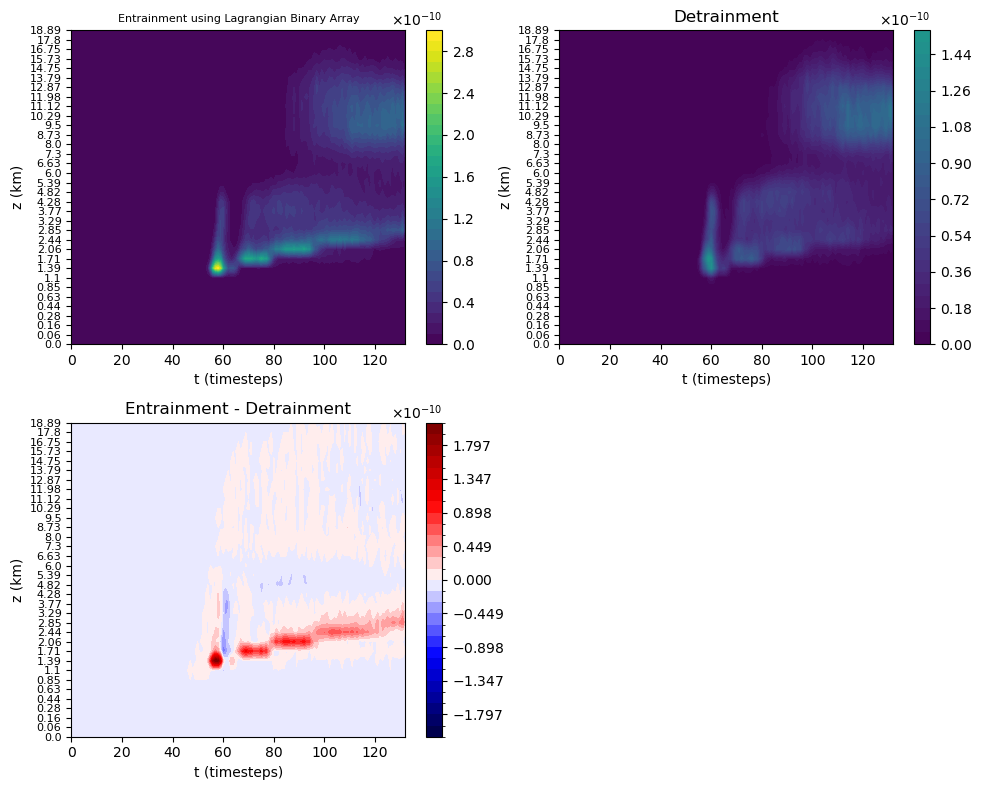

In [4]:
type='general'
type='cloudy'

if type=="general":
    profile_array_e_init=profile_array_e_g
    profile_array_d_init=profile_array_d_g
if type=="cloudy":
    profile_array_e_init=profile_array_e_c
    profile_array_d_init=profile_array_d_c

#APPLY CONSTANTS TO ENTRAINMENT VALUE
##################################################
profile_array_e=apply_constant(profile_array_e_init,True)
profile_array_d=apply_constant(profile_array_d_init,True)
##################################################

#Entrainment
profile_array_e = np.sum(profile_array_e_init, axis=(2, 3))*(dy*dx)/(Ly*Lx)
#Detrainment
profile_array_d = np.sum(profile_array_d_init, axis=(2, 3))*(dy*dx)/(Ly*Lx)
#Net
profile_array_net=profile_array_e_init-profile_array_d_init
profile_array_net=np.sum(profile_array_net,axis=(2, 3))*(dy*dx)/(Ly*Lx)

#Plotting
############################################################
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, figure=fig)

######
cmap1 = plt.cm.viridis
cmap2 = plt.cm.seismic 
n_levels=29
######

######
vmax_shared = np.max([np.max(profile_array_e), np.max(profile_array_d)])
norm_shared = mcolors.Normalize(vmin=0, vmax=vmax_shared)
######

# First subplot: Entrainment
########################################
ax1 = fig.add_subplot(gs[0, 0])
# contour1 = ax1.contourf(profile_array_e.T, cmap=cmap1)
contour1 = ax1.contourf(profile_array_e.T, cmap=cmap1, norm=norm_shared, levels=n_levels)
cbar1=fig.colorbar(contour1, ax=ax1)
Nz = len(data['zh'])
ax1.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax1.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax1.set_ylabel('z (km)');ax1.set_xlabel('t (timesteps)')
ax1.set_title('Entrainment using Lagrangian Binary Array',fontsize=8)

# Second subplot: Detrainment
########################################
ax2 = fig.add_subplot(gs[0, 1])
# contour2 = ax2.contourf(profile_array_d.T, cmap=cmap1)
contour2 = ax2.contourf(profile_array_d.T, cmap=cmap1, norm=norm_shared, levels=n_levels)
cbar2 = fig.colorbar(contour2, ax=ax2)
ax2.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax2.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax2.set_ylabel('z (km)');ax2.set_xlabel('t (timesteps)')
ax2.set_title('Detrainment')

# Third subplot: Net Entrainment
########################################


# #OLD METHOD, DOESNT BALANCE COLOR LEVELS
# # Normalize with a balanced vmin and vmax
# levels=49; vmin=np.min(profile_array_net);vmax=np.max(profile_array_net)
# # vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
# norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# Normalize with a balanced vmin and vmax
vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
levels = np.linspace(vmin, vmax, n_levels)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)
cmap = plt.get_cmap('RdBu_r', n_levels)

ax3 = fig.add_subplot(gs[1, 0])
contour3 = ax3.contourf((profile_array_net).T, cmap=cmap2, norm=norm, levels=levels)
# contour3 = ax3.contourf((profile_array_net).T, cmap=cmap2, levels=30,vmin=-np.max(abs(profile_array_net)), vmax=+np.max(abs(profile_array_net)))
# cmap2 = plt.get_cmap('RdBu', 29);contour3 = ax3.pcolor(profile_array_net.T, cmap=cmap2, norm=norm, shading='auto')
cbar3 = fig.colorbar(contour3, ax=ax3, norm=norm)

#FIXING TICKS
ax3.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax3.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax3.set_ylabel('z (km)');ax3.set_xlabel('t (timesteps)')
ax3.set_title('Entrainment - Detrainment')

#FIXING SCIENTIFIC NOTATION

def apply_scientific_notation_colorbar(cbars):
    from matplotlib.ticker import ScalarFormatter
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-2, 2))  # Adjust the range for scientific notation
    for cbar in cbars:  # These must be Colorbar instances
        cbar.formatter = formatter
        cbar.update_ticks()
apply_scientific_notation_colorbar([cbar1,cbar2,cbar3])

# Display the plot
plt.tight_layout()

#TESTING
print(f"Max of profile_array_e: {np.max(profile_array_e)}")
print(f"Max of profile_array_d: {np.max(profile_array_d)}")

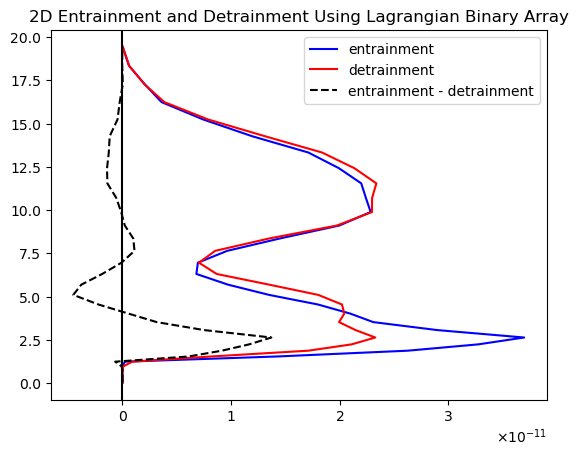

In [6]:
Lt=133*5*60; dt=300
e=np.sum(profile_array_e,axis=(0))*dt/Lt
d=np.sum(profile_array_d,axis=(0))*dt/Lt
net=np.sum(profile_array_e-profile_array_d,axis=(0))*dt/Lt

plt.plot(e,data['zh'],color='blue',label='entrainment')
plt.plot(d,data['zh'],color='red',label='detrainment')
plt.plot(net,data['zh'],linestyle='dashed',color='black',label='entrainment - detrainment')
plt.axvline(0,color='black')

plt.legend(); plt.title('2D Entrainment and Detrainment Using Lagrangian Binary Array')

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
plt.gca().xaxis.set_major_formatter(formatter)

In [ ]:
# type='general'
# type='cloudy'

# if type=="general":
#     profile_array_e=profile_array_e_g
#     profile_array_d=profile_array_d_g
# if type=="cloudy":
#     profile_array_e=profile_array_e_c
#     profile_array_d=profile_array_d_c

# #APPLY CONSTANTS TO ENTRAINMENT VALUE
# ##################################################
# profile_array_e=apply_constant(profile_array_e,True)
# profile_array_d=apply_constant(profile_array_d,True)
# ##################################################


# import matplotlib.pyplot as plt
# from matplotlib.gridspec import GridSpec
# import numpy as np

# fig = plt.figure(figsize=(10, 8))
# gs = GridSpec(2, 2, figure=fig)

# ######
# cmap1 = plt.cm.viridis
# cmap2 = plt.cm.seismic 
# n_levels=29
# ######


# out1 = np.sum(profile_array_e, axis=(2))
# out1 = np.mean(out1, axis=(0))
# # out1 = np.sum(profile_array_e, axis=(2, 3))
# out2 = np.sum(profile_array_d, axis=(2))
# out2 = np.mean(out2, axis=(0))
# # out1*=(Lx*Ly)/(dx*dy);out2*=(Lx*Ly)/(dx*dy)

# ######
# vmax_shared = np.max([np.max(out1), np.max(out2)])
# norm_shared = mcolors.Normalize(vmin=0, vmax=vmax_shared)
# ######

# # First subplot: Entrainment
# ########################################
# ax1 = fig.add_subplot(gs[0, 0])
# contour1 = ax1.contourf(out1, cmap=cmap1, norm=norm_shared, levels=n_levels)
# cbar1=fig.colorbar(contour1, ax=ax1)
# Nz = len(data['zh'])
# ax1.set_yticks(np.arange(Nz))
# new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
# ax1.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
# ax1.set_ylabel('z (km)');ax1.set_xlabel('t (timesteps)')
# ax1.set_title('Entrainment using Lagrangian Binary Array',fontsize=8)

# # Second subplot: Detrainment
# ########################################
# ax2 = fig.add_subplot(gs[0, 1])
# contour2 = ax2.contourf(out2, cmap=cmap1, norm=norm_shared, levels=n_levels)
# cbar2 = fig.colorbar(contour2, ax=ax2)
# ax2.set_yticks(np.arange(Nz))
# new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
# ax2.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
# ax2.set_ylabel('z (km)');ax2.set_xlabel('t (timesteps)')
# ax2.set_title('Detrainment')

# # Third subplot: Net Entrainment
# ########################################
# profile_array_net=profile_array_e-profile_array_d
# profile_array_net=np.sum(profile_array_net,axis=(2, 3))

# # #OLD METHOD, DOESNT BALANCE COLOR LEVELS
# # # Normalize with a balanced vmin and vmax
# # levels=49; vmin=np.min(profile_array_net);vmax=np.max(profile_array_net)
# # # vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
# # norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# # Normalize with a balanced vmin and vmax
# vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
# levels = np.linspace(vmin, vmax, n_levels)
# norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)
# cmap = plt.get_cmap('RdBu_r', n_levels)

# ax3 = fig.add_subplot(gs[1, 0])
# contour3 = ax3.contourf((profile_array_net).T, cmap=cmap2, norm=norm, levels=levels)
# # contour3 = ax3.contourf((profile_array_net).T, cmap=cmap2, levels=30,vmin=-np.max(abs(profile_array_net)), vmax=+np.max(abs(profile_array_net)))
# # cmap2 = plt.get_cmap('RdBu', 29);contour3 = ax3.pcolor(profile_array_net.T, cmap=cmap2, norm=norm, shading='auto')
# cbar3 = fig.colorbar(contour3, ax=ax3, norm=norm)

# #FIXING TICKS
# ax3.set_yticks(np.arange(Nz))
# new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
# ax3.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
# ax3.set_ylabel('z (km)');ax3.set_xlabel('t (timesteps)')
# ax3.set_title('Entrainment - Detrainment')

# #FIXING SCIENTIFIC NOTATION

# def apply_scientific_notation_colorbar(cbars):
#     from matplotlib.ticker import ScalarFormatter
#     formatter = ScalarFormatter(useMathText=True)
#     formatter.set_powerlimits((-2, 2))  # Adjust the range for scientific notation
#     for cbar in cbars:  # These must be Colorbar instances
#         cbar.formatter = formatter
#         cbar.update_ticks()
# apply_scientific_notation_colorbar([cbar1,cbar2,cbar3])

# # Display the plot
# plt.tight_layout()